# Fine-Tuning: Speaker-Turn Attention Pooling Model

Trains a model that predicts whether an earnings call's excess return
(stock return minus S&P 500 return over a lag window) was positive, from
the transcript text alone. The architecture — per-speaker-turn FinBERT
encoding + a learned attention-pooling head over turns, tagged by speaker
role (CEO/CFO/IR/analyst/etc.) — is explained in full in
`docs/model_architecture.md`; that document also records *why* this
approach was chosen over feeding the whole (~12-15k token) transcript to a
single encoder. Read it first if anything below is unclear.

This notebook is a **technique demonstration on a bounded subset/budget of
the data**, not a full-dataset production run — see the `SAMPLE_FRACTION`,
`AUTOGLUON_TIME_LIMIT`, `N_OPTUNA_TRIALS`, and `MAX_EPOCHS` constants
defined immediately before the sections they govern. This keeps the
notebook fast to re-run end-to-end while still demonstrating every
technique in full.

Two independent modeling approaches are compared:

- **Section A — Tabular AutoML baseline**: per-speaker-role FinBERT
  sentiment scores, aggregated into tabular features, fed to AutoGluon.
- **Section B — Deep model + hyperparameter search**: the attention-pooling
  model itself, with an Optuna search over its hyperparameters.

Both sections report train-vs-validation performance explicitly (to check
for over/underfitting) and a confusion matrix on a held-out, chronologically
later test set.

**Prerequisite**: run the (expensive, one-time) turn-encoding cache first:

```
uv run python src/modeling/cli/precompute_turn_features.py
```

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from modeling.turns import parse_turns, classify_role, Role
from modeling.features import aggregate_tabular_features
from modeling.dataset import TurnFeatureDataset, collate_fn
from modeling.model import AttentionPoolingClassifier
from modeling.training import (
    time_based_split,
    train_model,
    predict,
    plot_training_curves,
    plot_confusion_matrix,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

TRANSCRIPTS_PATH = PROJECT_ROOT / "data" / "generated" / "labeled_transcripts.parquet"
TURN_FEATURES_DIR = PROJECT_ROOT / "data" / "generated" / "turn_features"

Using device: cuda


## 1. Load data

`labeled_transcripts.parquet` is the transcript + excess-return-label table
built by `src/datawrangling/`. `turn_metadata.parquet` /
`turn_embeddings.npy` are the precomputed per-turn FinBERT outputs
(`cli/precompute_turn_features.py`) — one embedding + one set of sentiment
scores per speaker turn, row-aligned between the two files.

In [2]:
transcripts = pd.read_parquet(TRANSCRIPTS_PATH)
transcripts["call_date"] = pd.to_datetime(transcripts["call_date"])

turn_metadata = pd.read_parquet(TURN_FEATURES_DIR / "turn_metadata.parquet")
turn_embeddings = np.load(TURN_FEATURES_DIR / "turn_embeddings.npy")

print(f"transcripts      : {transcripts.shape}")
print(f"turn_metadata    : {turn_metadata.shape}")
print(f"turn_embeddings  : {turn_embeddings.shape}")
assert len(turn_metadata) == len(turn_embeddings), "turn_metadata and turn_embeddings must be row-aligned"

transcripts      : (3056, 17)
turn_metadata    : (227787, 10)
turn_embeddings  : (227787, 768)


## 2. Turn-parsing validation

Before trusting any downstream feature, spot-check that `parse_turns` is
actually recovering speaker turns correctly — this is verification of the
*preprocessing* step, not just the final model.

In [3]:
sample_row = transcripts.iloc[0]
sample_turns = parse_turns(sample_row["transcript"])

print(f"Ticker: {sample_row['ticker']}, {len(sample_turns)} turns parsed\n")
for turn in sample_turns[:6]:
    print(f"[{turn.role.value:11s}] {turn.speaker} -- {turn.title}  ({turn.section})")
    print(f"    {turn.text[:120]}...\n")

Ticker: LRCX, 97 turns parsed

[operator   ] Operator --   (Prepared Remarks)
    Good day and welcome to the September 2019 Quarter Financial Call for Lam Research. At this time, I'd like to turn the c...

[ir         ] Tina Correia -- Vice President, Investor Relations & Corporate Communications  (Prepared Remarks)
    Thank you, operator. Thank you and good afternoon everyone, welcome to the Lam Research Quarterly Earnings Conference Ca...

[ceo        ] Tim Archer -- President and Chief Executive Officer  (Prepared Remarks)
    Thanks, Tina, and welcome everyone. In the September quarter Lam delivered solid results. Our continued execution to com...

[cfo        ] Doug Bettinger -- Executive Vice President and Chief Financial Officer  (Prepared Remarks)
    Okay, great. Thank you, Tim, and good afternoon everyone and thank you for joining us today. And what I know is a busy e...

[operator   ] Operator --   (Questions and Answers)
    Thank you. [Operator Instructions] And we'll ta

Role distribution across all cached turns:
role
analyst       80597
ceo           54995
operator      37758
cfo           29265
other_exec    13071
ir             8989
other          3112
Name: count, dtype: int64


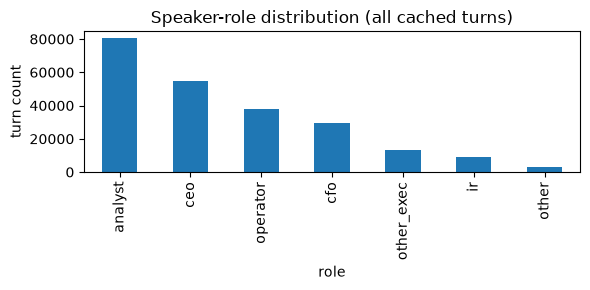

In [4]:
role_counts = turn_metadata["role"].value_counts()
print("Role distribution across all cached turns:")
print(role_counts)

fig, ax = plt.subplots(figsize=(6, 3))
role_counts.plot.bar(ax=ax)
ax.set_ylabel("turn count")
ax.set_title("Speaker-role distribution (all cached turns)")
fig.tight_layout()

## 3. Target framing, scope sampling, and the train/val/test split

**Target**: binary — did the call's excess return come out positive
(`excess_return_label > 0`)? This matches the eventual product goal
("confidence it will go up or down") and is more stable to fit than raw
regression at this dataset size (~3k rows).

**`SAMPLE_FRACTION`** bounds how much of the labeled dataset this notebook
run uses — applied *before* the split so split proportions and chronological
ordering still behave sensibly on the subset. Raise it for a more
data-hungry run; keep it low to iterate quickly.

**Split**: chronological, not random — see `time_based_split` in
`training.py` for why (a randomly shuffled split would leak future market
information into training, which a model deployed in production would never
have).

In [5]:
SAMPLE_FRACTION = 0.35  # fraction of the labeled dataset used below; raise for a fuller run

labels_df = pd.DataFrame(
    {
        "label": (transcripts["excess_return_label"] > 0).astype(int),
        "call_date": transcripts["call_date"],
    },
    index=transcripts.index,
)
labels_df.index.name = "row_id"

print("Class balance (full dataset):")
print(labels_df["label"].value_counts(normalize=True))

sampled_labels_df = labels_df.sample(frac=SAMPLE_FRACTION, random_state=42)
print(f"\nUsing {len(sampled_labels_df)} / {len(labels_df)} rows this run (SAMPLE_FRACTION={SAMPLE_FRACTION})")
print("Class balance (sampled subset):")
print(sampled_labels_df["label"].value_counts(normalize=True))

Class balance (full dataset):
label
1    0.518652
0    0.481348
Name: proportion, dtype: float64

Using 1070 / 3056 rows this run (SAMPLE_FRACTION=0.35)
Class balance (sampled subset):
label
1    0.521495
0    0.478505
Name: proportion, dtype: float64


In [6]:
train_labels, val_labels, test_labels = time_based_split(sampled_labels_df, train_frac=0.7, val_frac=0.15)

for name, split_df in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    print(
        f"{name:5s}: n={len(split_df):4d}  "
        f"dates=[{split_df['call_date'].min().date()} .. {split_df['call_date'].max().date()}]  "
        f"positive_rate={split_df['label'].mean():.3f}"
    )

train: n= 749  dates=[2017-11-22 .. 2022-01-27]  positive_rate=0.510
val  : n= 160  dates=[2022-01-27 .. 2022-07-26]  positive_rate=0.588
test : n= 161  dates=[2022-07-27 .. 2023-02-15]  positive_rate=0.509


### Viewing the train/val/test split

A direct look at the split actually used to train/evaluate the final
model — which transcripts landed in which split, and visual confirmation
that the split is chronological with no date overlap between splits (the
property `time_based_split` exists to guarantee; see its docstring in
`src/modeling/training.py`).

In [7]:
split_assignment = pd.concat(
    [
        train_labels.assign(split="train"),
        val_labels.assign(split="val"),
        test_labels.assign(split="test"),
    ]
).join(transcripts[["ticker"]])
split_assignment = split_assignment[["ticker", "call_date", "label", "split"]].sort_values("call_date")

split_summary = split_assignment.groupby("split", sort=False).agg(
    n=("label", "size"),
    date_min=("call_date", "min"),
    date_max=("call_date", "max"),
    positive_rate=("label", "mean"),
).loc[["train", "val", "test"]]
split_summary

,n,date_min,date_max,positive_rate
split,,,,
train,749,2017-11-22,2022-01-27,0.510013
val,160,2022-01-27,2022-07-26,0.587500
test,161,2022-07-27,2023-02-15,0.509317


In [8]:
split_assignment.head(10)

,ticker,call_date,label,split
row_id,,,,
1689,DE,2017-11-22,1,train
1525,LIN,2018-01-25,1,train
272,GOOGL,2018-02-01,1,train
542,HUBS,2018-05-10,1,train
940,AXP,2018-07-18,0,train
555,MS,2018-07-18,0,train
1340,MCD,2018-07-26,1,train
927,HON,2018-10-19,0,train
1268,MCD,2018-10-23,1,train


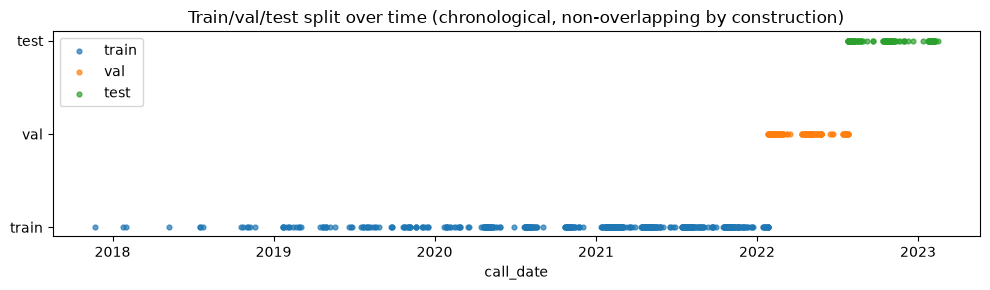

In [9]:
SPLIT_ORDER = ["train", "val", "test"]
SPLIT_Y = {split: i for i, split in enumerate(SPLIT_ORDER)}
SPLIT_COLOR = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green"}

fig, ax = plt.subplots(figsize=(10, 3))
for split in SPLIT_ORDER:
    subset = split_assignment[split_assignment["split"] == split]
    ax.scatter(
        subset["call_date"],
        [SPLIT_Y[split]] * len(subset),
        color=SPLIT_COLOR[split],
        label=split,
        s=12,
        alpha=0.7,
    )

ax.set_yticks(list(SPLIT_Y.values()))
ax.set_yticklabels(SPLIT_ORDER)
ax.set_xlabel("call_date")
ax.set_title("Train/val/test split over time (chronological, non-overlapping by construction)")
ax.legend(loc="upper left")
fig.tight_layout()

## Section A — Tabular AutoML baseline

Aggregates per-speaker-role FinBERT sentiment scores (mean/std per role +
turn counts, from `aggregate_tabular_features`) into one feature row per
transcript, then lets AutoGluon pick and tune a model over that tabular
representation. This is a fast, interpretable baseline to compare the deep
model in Section B against.

`AUTOGLUON_TIME_LIMIT` caps AutoGluon's search wall-clock time.

In [10]:
tabular_features = aggregate_tabular_features(turn_metadata).set_index("row_id")

def build_tabular_split(label_split_df):
    joined = tabular_features.join(label_split_df[["label"]], how="inner")
    return joined

tabular_train = build_tabular_split(train_labels)
tabular_val = build_tabular_split(val_labels)
tabular_test = build_tabular_split(test_labels)

print(f"tabular_train: {tabular_train.shape}, tabular_val: {tabular_val.shape}, tabular_test: {tabular_test.shape}")
tabular_train.head()

tabular_train: (749, 51), tabular_val: (160, 51), tabular_test: (161, 51)


,analyst__sentiment_positive_mean,ceo__sentiment_positive_mean,cfo__sentiment_positive_mean,ir__sentiment_positive_mean,operator__sentiment_positive_mean,other__sentiment_positive_mean,other_exec__sentiment_positive_mean,analyst__sentiment_positive_std,ceo__sentiment_positive_std,cfo__sentiment_positive_std,...,other_exec__sentiment_neutral_std,analyst__n_turns,ceo__n_turns,cfo__n_turns,ir__n_turns,operator__n_turns,other__n_turns,other_exec__n_turns,total_turns,label
row_id,,,,,,,,,,,,,,,,,,,,,
0,0.376342,0.459914,0.276416,0.284066,0.072603,0.000000,0.000000,0.306958,0.347732,0.219972,...,0.000000,38.0,21.0,21.0,2.0,15.0,0.0,0.0,97,1
7,0.372555,0.308570,0.572639,0.041063,0.047379,0.000000,0.000000,0.273176,0.286752,0.289788,...,0.000000,15.0,4.0,10.0,1.0,10.0,0.0,0.0,40,0
12,0.204007,0.083149,0.647839,0.436194,0.039437,0.136599,0.420418,0.171501,0.037770,0.342470,...,0.326063,15.0,6.0,6.0,14.0,16.0,1.0,7.0,65,0
14,0.311859,0.208838,0.444208,0.048532,0.038754,0.000000,0.477933,0.259811,0.261756,0.440296,...,0.259128,19.0,11.0,3.0,17.0,15.0,0.0,10.0,75,1
22,0.258444,0.275569,0.204258,0.030874,0.030942,0.000000,0.372605,0.257577,0.267808,0.274453,...,0.295986,25.0,14.0,12.0,1.0,8.0,0.0,4.0,64,0


In [11]:
AUTOGLUON_TIME_LIMIT = 120  # seconds; wall-clock cap on AutoGluon's search

from autogluon.tabular import TabularPredictor

autogluon_predictor = TabularPredictor(
    label="label",
    problem_type="binary",
    eval_metric="accuracy",
    path=str(PROJECT_ROOT / "data" / "generated" / "models" / "autogluon_tabular"),
    verbosity=1,
).fit(
    train_data=tabular_train,
    tuning_data=tabular_val,
    time_limit=AUTOGLUON_TIME_LIMIT,
)

autogluon_predictor.leaderboard(tabular_test)

		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.6.1`.


		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.6.1`.


		`import catboost` failed. A quick tip is to install via `pip install autogluon.tabular[catboost]==1.6.1`.


		Import fastai failed. A quick tip is to install via `pip install autogluon.tabular[fastai]==1.6.1`. 


		`import xgboost` failed. A quick tip is to install via `pip install autogluon.tabular[xgboost]==1.6.1`.


		`import lightgbm` failed. A quick tip is to install via `pip install autogluon.tabular[lightgbm]==1.6.1`.


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetTorch,0.590062,0.58750,accuracy,0.010604,0.010775,2.530188,0.010604,0.010775,2.530188,1,True,5
1,WeightedEnsemble_L2,0.583851,0.60000,accuracy,0.085142,0.065341,2.996566,0.001368,0.000829,0.027043,2,True,6
2,ExtraTreesGini,0.527950,0.53125,accuracy,0.066622,0.064139,0.451291,0.066622,0.064139,0.451291,1,True,3
3,ExtraTreesEntr,0.527950,0.55000,accuracy,0.073170,0.053738,0.439335,0.073170,0.053738,0.439335,1,True,4
4,RandomForestEntr,0.515528,0.49375,accuracy,0.060702,0.054126,0.580415,0.060702,0.054126,0.580415,1,True,2
5,RandomForestGini,0.509317,0.47500,accuracy,0.064332,0.063938,0.613403,0.064332,0.063938,0.613403,1,True,1


In [12]:
# Train-vs-validation score comparison is this section's over/underfitting check:
# a large gap between train and val/test accuracy indicates overfitting on the
# (small, engineered) feature set.
train_acc = autogluon_predictor.evaluate(tabular_train)["accuracy"]
val_acc = autogluon_predictor.evaluate(tabular_val)["accuracy"]
test_acc = autogluon_predictor.evaluate(tabular_test)["accuracy"]
print(f"train accuracy: {train_acc:.3f}")
print(f"val   accuracy: {val_acc:.3f}")
print(f"test  accuracy: {test_acc:.3f}")

autogluon_predictor.feature_importance(tabular_test)

train accuracy: 0.716
val   accuracy: 0.600
test  accuracy: 0.584


,importance,stddev,p_value,n,p99_high,p99_low
other_exec__sentiment_negative_mean,0.047205,0.033042,0.016537,5,0.115239,-0.020829
ir__sentiment_neutral_std,0.040994,0.007082,0.000103,5,0.055575,0.026412
ir__sentiment_negative_mean,0.039752,0.014299,0.001704,5,0.069194,0.010309
ir__sentiment_positive_std,0.038509,0.011947,0.000982,5,0.063109,0.013909
analyst__sentiment_negative_mean,0.033540,0.012880,0.002166,5,0.060060,0.007021
cfo__sentiment_neutral_std,0.021118,0.007082,0.001314,5,0.035700,0.006536
operator__sentiment_negative_mean,0.021118,0.016197,0.021720,5,0.054467,-0.012231
cfo__sentiment_negative_std,0.019876,0.009213,0.004249,5,0.038845,0.000907
ceo__sentiment_positive_mean,0.018634,0.006211,0.001285,5,0.031422,0.005845
cfo__sentiment_negative_mean,0.018634,0.009821,0.006618,5,0.038855,-0.001587


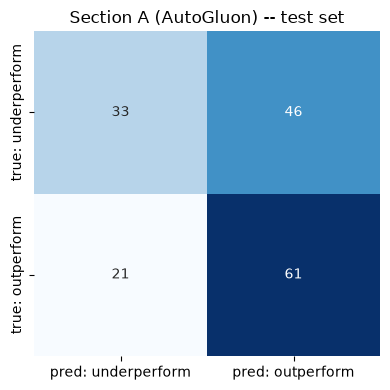

In [13]:
tabular_preds = autogluon_predictor.predict(tabular_test.drop(columns=["label"]))
fig = plot_confusion_matrix(tabular_test["label"].tolist(), tabular_preds.tolist(), title="Section A (AutoGluon) -- test set")

## Section B — Deep attention-pooling model + hyperparameter search

Trains the actual architecture described in `docs/model_architecture.md`
directly on the cached per-turn FinBERT embeddings (not the aggregated
tabular features from Section A — the attention layer learns its own
turn-importance weighting instead of a hand-aggregated mean/std).

Optuna searches the head's hyperparameters (learning rate, weight decay,
attention width, role-embedding width, dropout) using the **cached**
embeddings, so each trial only trains the small attention-pooling head —
no repeated FinBERT forward passes. `N_OPTUNA_TRIALS` and `MAX_EPOCHS` cap
the search and per-trial training budget respectively.

In [14]:
EMBEDDING_DIM = turn_embeddings.shape[1]

train_dataset = TurnFeatureDataset(turn_metadata, turn_embeddings, train_labels["label"])
val_dataset = TurnFeatureDataset(turn_metadata, turn_embeddings, val_labels["label"])
test_dataset = TurnFeatureDataset(turn_metadata, turn_embeddings, test_labels["label"])

from torch.utils.data import DataLoader

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)

In [15]:
N_OPTUNA_TRIALS = 10   # search budget
MAX_EPOCHS = 15        # per-trial (and final-run) training depth cap

import optuna

def objective(trial):
    model = AttentionPoolingClassifier(
        embedding_dim=EMBEDDING_DIM,
        role_dim=trial.suggest_categorical("role_dim", [8, 16, 32]),
        attention_dim=trial.suggest_categorical("attention_dim", [64, 128, 256]),
        dropout=trial.suggest_float("dropout", 0.0, 0.5),
    )
    history = train_model(
        model,
        train_loader,
        val_loader,
        max_epochs=MAX_EPOCHS,
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        weight_decay=trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        device=DEVICE,
        patience=4,
    )
    return min(history.val_loss)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=N_OPTUNA_TRIALS)

print("Best val loss:", study.best_value)
print("Best params:", study.best_params)

/home/nflanaga/ML2026/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Best val loss: 0.669311773777008
Best params: {'role_dim': 8, 'attention_dim': 128, 'dropout': 0.22859691209140187, 'lr': 0.0020898292723808168, 'weight_decay': 1.2638728260057007e-05}


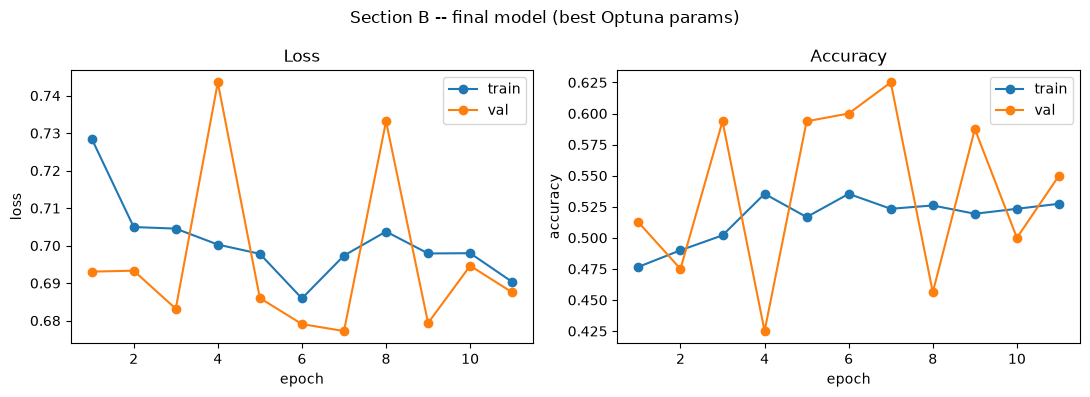

In [16]:
best_params = study.best_params
final_model = AttentionPoolingClassifier(
    embedding_dim=EMBEDDING_DIM,
    role_dim=best_params["role_dim"],
    attention_dim=best_params["attention_dim"],
    dropout=best_params["dropout"],
)
final_history = train_model(
    final_model,
    train_loader,
    val_loader,
    max_epochs=MAX_EPOCHS,
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"],
    device=DEVICE,
    patience=4,
)

fig = plot_training_curves(final_history, title="Section B -- final model (best Optuna params)")

The curves above are the direct over/underfitting check for the deep model:
a widening train/val loss gap would indicate overfitting (mitigated here by
early stopping via `patience`, and by `dropout` being one of the searched
hyperparameters); both curves plateauing at a high loss would indicate
underfitting (mitigated by the Optuna search itself finding an adequate
learning rate / capacity).

Section B test accuracy: 0.547


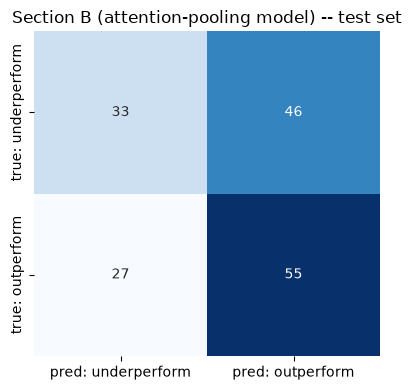

In [17]:
y_true, y_pred = predict(final_model, test_loader, device=DEVICE)
test_accuracy = sum(int(a == b) for a, b in zip(y_true, y_pred)) / len(y_true)
print(f"Section B test accuracy: {test_accuracy:.3f}")

fig = plot_confusion_matrix(y_true, y_pred, title="Section B (attention-pooling model) -- test set")

### Attention-weight inspection

The attention weights over turns double as an interpretability signal —
which speaker/turn the model leaned on for a given prediction. This is the
"officer score" concept from the original design discussion: discovered by
the model, not hand-specified.

In [18]:
final_model.eval()
example_row_id = test_labels.index[0]
example_transcript = transcripts.loc[example_row_id, "transcript"]
example_turns = parse_turns(example_transcript)

example_batch = collate_fn([test_dataset[test_dataset.row_ids.index(example_row_id)]])
with torch.no_grad():
    logits, attn_weights = final_model(
        example_batch["embeddings"].to(DEVICE),
        example_batch["role_ids"].to(DEVICE),
        example_batch["attention_mask"].to(DEVICE),
    )

weights = attn_weights[0, : len(example_turns)].cpu().numpy()
predicted_label = int(logits.item() > 0)
actual_label = int(test_labels.loc[example_row_id, "label"])
print(f"Transcript row_id={example_row_id}, predicted={predicted_label}, actual={actual_label}\n")

top_turns = sorted(zip(weights, example_turns), key=lambda pair: pair[0], reverse=True)[:5]
for weight, turn in top_turns:
    print(f"  attn={weight:.3f}  [{turn.role.value:9s}] {turn.speaker}: {turn.text[:100]}...")

Transcript row_id=772, predicted=1, actual=1

  attn=0.324  [analyst  ] Tyler Brown: Good morning....
  attn=0.248  [cfo      ] Devina Rankin: Good morning, Tyler....
  attn=0.078  [ceo      ] Jim Fish: Thanks, Ed, and thank you all for joining us. The strength and resiliency of our business was clearl...
  attn=0.066  [other_exec] John Morris: Thanks, Jim, and good morning, everyone. Once again, we achieved exceptional organic revenue growth ...
  attn=0.044  [cfo      ] Devina Rankin: Thanks, John, and good morning. The strong operating and financial results of the second quarter con...


## 4. Section A vs. Section B comparison

In [19]:
comparison = pd.DataFrame(
    [
        {"section": "A (AutoGluon tabular)", "train_acc": train_acc, "val_acc": val_acc, "test_acc": test_acc},
        {
            "section": "B (attention-pooling)",
            "train_acc": final_history.train_acc[-1],
            "val_acc": final_history.val_acc[-1],
            "test_acc": test_accuracy,
        },
    ]
)
comparison

,section,train_acc,val_acc,test_acc
0,A (AutoGluon tabular),0.715621,0.60,0.583851
1,B (attention-pooling),0.527370,0.55,0.546584


## 5. Save artifacts

Saved for the later SageMaker packaging phase (not wired up in this
notebook — see project memory / `docs/model_architecture.md` for the
broader roadmap).

In [20]:
MODELS_DIR = PROJECT_ROOT / "data" / "generated" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "state_dict": final_model.state_dict(),
        "embedding_dim": EMBEDDING_DIM,
        "role_dim": best_params["role_dim"],
        "attention_dim": best_params["attention_dim"],
        "dropout": best_params["dropout"],
    },
    MODELS_DIR / "attention_pooling_model.pt",
)
print(f"Saved final model to {MODELS_DIR / 'attention_pooling_model.pt'}")
print(f"AutoGluon predictor already saved under {MODELS_DIR / 'autogluon_tabular'}")

Saved final model to /home/nflanaga/ML2026/data/generated/models/attention_pooling_model.pt
AutoGluon predictor already saved under /home/nflanaga/ML2026/data/generated/models/autogluon_tabular
